# Appendix

## 1. Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import shapely
from shapely.wkt import loads

import pandas as pd
import geopandas as gpd
import mapclassify as mp

import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

import palettable.colorbrewer.sequential as pcs
import palettable.colorbrewer.diverging as pcd

from libpysal import weights
from pysal.explore import esda
from splot import esda as esdaplot

import numba
numba.__version__


'0.61.2'

## 2. Import Data

In [4]:
census = pd.read_csv('UKCensus-21-11-London-21geog-data.csv')
aq     = pd.read_csv('AirQuality-13-16-19-London-21geog-data.csv')

df = pd.merge(census, aq, on='LSOA21CD')

lsoa_gdf = gpd.GeoDataFrame(df)
lsoa_gdf['geometry'] = lsoa_gdf['geometry'].apply(lambda x: loads(x))
lsoa_gdf = lsoa_gdf.set_geometry('geometry')

print(lsoa_gdf.shape)
lsoa_gdf[['LSOA21CD', 'LAD22NM', 'NO2-2013-mean', 'NO2-2019-mean']].head()

(4994, 130)


,LSOA21CD,LAD22NM,NO2-2013-mean,NO2-2019-mean
0,E01000001,City of London,57.812,42.849
1,E01000002,City of London,47.683,38.842
2,E01000003,City of London,47.176,38.780
3,E01000005,City of London,61.116,39.982
4,E01000006,Barking and Dagenham,32.585,26.619


In [5]:
print(lsoa_gdf.columns.tolist())

['LSOA21CD', 'LSOA21NM', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LSOA21KM2', 'LSOAP21', 'CHGIND', 'geometry', 'TotRes21', 'TotRes11_m21', 'TotHHolds21', 'TotHHolds11_m21', 'FemRes21', 'FemRes11_m21', 'MalRes21', 'MalRes11_m21', 'Asian21', 'Asian11_m21', 'Black21', 'Black11_m21', 'MixedE21', 'MixedE11_m21', 'White21', 'White11_m21', 'OtherE21', 'OtherE11_m21', 'CarsZero21', 'CarsZero11_m21', 'CarsOne21', 'CarsOne11_m21', 'CarsTwo21', 'CarsTwo11_m21', 'CarsThrp21', 'CarsThrp11_m21', 'EconEm21', 'EconEm11_m21', 'EconUn21', 'EconUn11_m21', 'EconSt21', 'EconSt11_m21', 'EconRe21', 'EconRe11_m21', 'EconOt21', 'EconOt11_m21', 'AgeChild21', 'AgeChild11_m21', 'AgeAdult21', 'AgeAdult11_m21', 'AgeSenior21', 'AgeSenior11_m21', 'HealthVG21', 'HealthVG11_m21', 'HealthGood21', 'HealthGood11_m21', 'HealthFair21', 'HealthFair11_m21', 'HealthBad21', 'HealthBad11_m21', 'HealthVB21', 'HealthVB11_m21', 'QualNone21', 'QualNone11_m21', 'QualSch21', 'QualSch11_m21', 'QualUni21', 'QualUni11_m21', 'QualOt

## 3. Derived Variable

In [6]:
lsoa_gdf['NO2_AbsD'] = lsoa_gdf['NO2-2019-mean'] - lsoa_gdf['NO2-2013-mean']
lsoa_gdf['NO2_PerD'] = 100 * lsoa_gdf['NO2_AbsD'] / lsoa_gdf['NO2-2013-mean']

lsoa_gdf.loc[lsoa_gdf['CHGIND'] == 'S', 'NO2_AbsD'] = None
lsoa_gdf.loc[lsoa_gdf['CHGIND'] == 'S', 'NO2_PerD'] = None

lsoa_gdf['pct_no_car'] = lsoa_gdf['CarsZero21'] / lsoa_gdf['TotHHolds21'] * 100

lsoa_gdf['pct_nonwhite'] = (lsoa_gdf['Asian21'] + lsoa_gdf['Black21'] +
                             lsoa_gdf['MixedE21'] + lsoa_gdf['OtherE21']) / lsoa_gdf['TotRes21'] * 100

lsoa_gdf[['NO2_AbsD', 'NO2_PerD', 'pct_no_car', 'pct_nonwhite']].describe()

,NO2_AbsD,NO2_PerD,pct_no_car,pct_nonwhite
count,4681.000000,4681.000000,4994.000000,4994.000000
mean,-7.770090,-21.275476,40.542064,45.190635
std,2.535003,3.496376,19.131674,18.706506
min,-27.785000,-39.295968,3.983229,3.319502
25%,-8.886000,-23.292219,24.836426,30.217461
50%,-7.318000,-21.232623,39.020980,43.770201
75%,-6.072000,-18.791603,56.394762,58.859175
max,-2.491000,-6.637357,89.760000,98.092532


 ## 4. Borough Level Aggregation

In [7]:
aq_cols = ['NO2-2013-mean', 'NO2-2016-mean', 'NO2-2019-mean', 'NO2_AbsD', 'NO2_PerD']
boros_aq = lsoa_gdf.groupby('LAD22NM')[aq_cols].mean().reset_index()

boros_census = lsoa_gdf.groupby('LAD22NM').sum(numeric_only=True).reset_index()
boros_census['pct_no_car'] = boros_census['CarsZero21'] / boros_census['TotHHolds21'] * 100
boros_census['pct_nonwhite'] = (boros_census['Asian21'] + boros_census['Black21'] +
                                 boros_census['MixedE21'] + boros_census['OtherE21']) / boros_census['TotRes21'] * 100

lad = gpd.read_file('boroughs/london-2021-lad22-gen20.shp')
lad_gdf = pd.merge(lad, boros_aq, on='LAD22NM')
lad_gdf = pd.merge(lad_gdf, boros_census[['LAD22NM', 'pct_no_car', 'pct_nonwhite']], on='LAD22NM')

print(lad_gdf.shape)
lad_gdf[['LAD22NM', 'NO2-2013-mean', 'NO2-2016-mean', 'NO2-2019-mean', 'NO2_AbsD']].head()

(33, 10)


,LAD22NM,NO2-2013-mean,NO2-2016-mean,NO2-2019-mean,NO2_AbsD
0,Barking and Dagenham,31.851287,32.450748,25.280313,-6.543467
1,Barnet,33.977995,34.820905,27.485018,-6.442795
2,Bexley,30.254574,30.821824,24.254959,-6.003069
3,Brent,36.896420,37.552166,29.113061,-7.750743
4,Bromley,29.382935,29.786281,22.880930,-6.468072


## 5. Exploratory Data Analysis

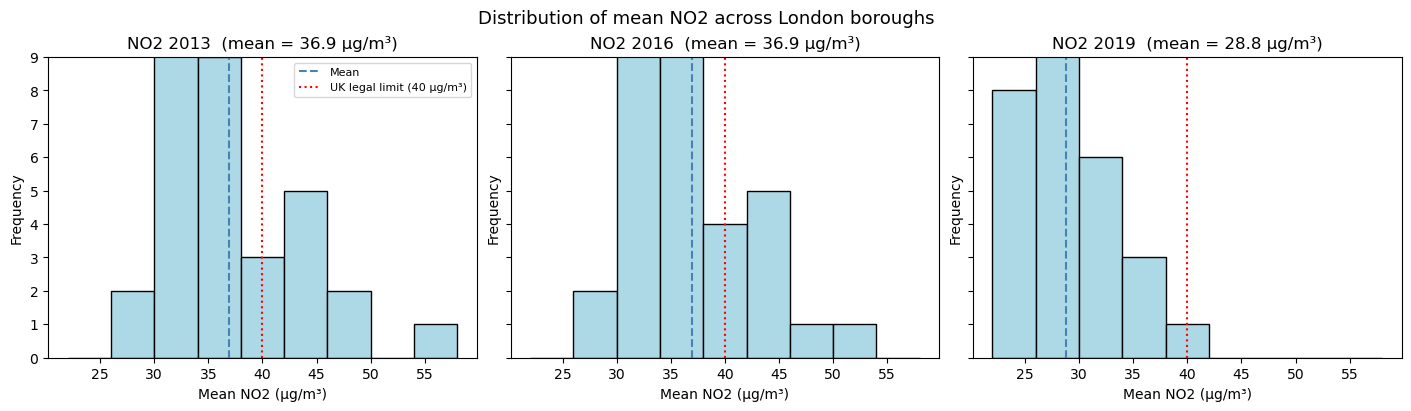

In [8]:
cbins = [22, 26, 30, 34, 38, 42, 46, 50, 54, 58]

fig, axs = plt.subplots(1, 3, figsize=(14, 4), layout='constrained', sharex=True, sharey=True)

means = {'2013': 36.9, '2016': 36.9, '2019': 28.8}

for ax, yr in zip(axs, ['2013', '2016', '2019']):
    ax.hist(lad_gdf[f'NO2-{yr}-mean'], bins=cbins, facecolor='lightblue', edgecolor='black')
    ax.axvline(lad_gdf[f'NO2-{yr}-mean'].mean(), c='steelblue', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(40, c='red', linestyle=':', linewidth=1.5, label='UK legal limit (40 μg/m³)')
    ax.set_title(f'NO2 {yr}  (mean = {round(lad_gdf[f"NO2-{yr}-mean"].mean(), 1)} μg/m³)')
    ax.set_xlabel('Mean NO2 (μg/m³)')
    ax.set_ylabel('Frequency')
    ax.set_ylim(0, 9)

axs[0].legend(fontsize=8, loc='upper right')

plt.suptitle('Distribution of mean NO2 across London boroughs', fontsize=13)
plt.savefig('figS1_histograms.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Results

### Figure 1

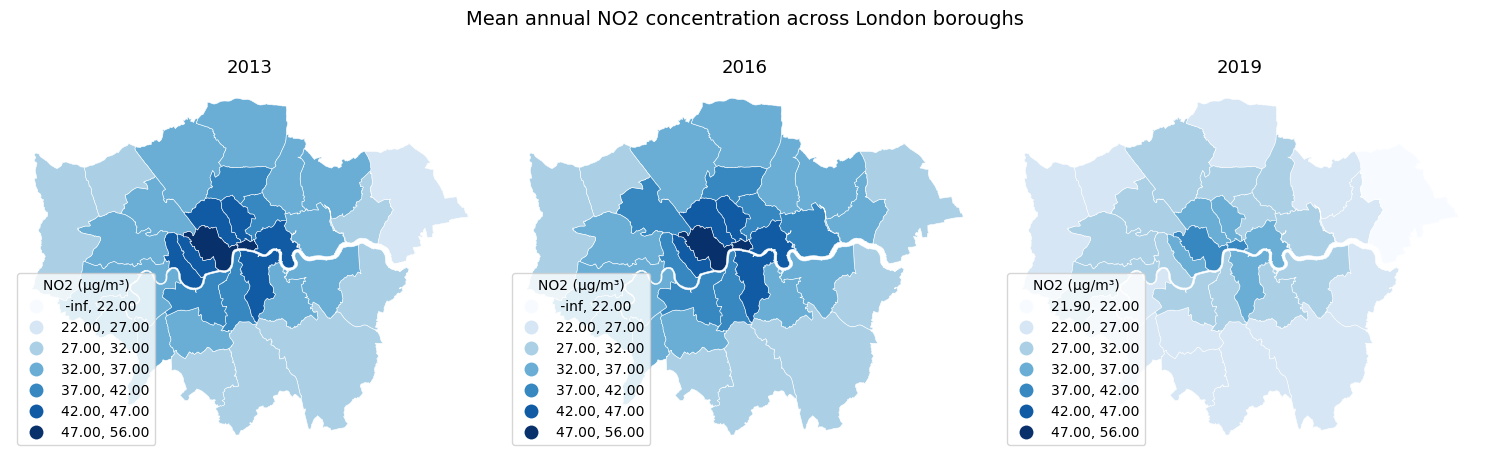

In [11]:
cbins_no2 = [22, 27, 32, 37, 42, 47, 56]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, yr in zip(axs, ['2013', '2016', '2019']):
    lad_gdf.plot(column=f'NO2-{yr}-mean', ax=ax,
                 scheme='UserDefined',
                 classification_kwds={'bins': cbins_no2},
                 cmap='Blues',
                 edgecolor='white', linewidth=0.4,
                 legend=True,
                 legend_kwds={'title': 'NO2 (μg/m³)', 'loc': 'lower left'})
    ax.set_title(yr, fontsize=13)
    ax.axis('off')

fig.suptitle('Mean annual NO2 concentration across London boroughs', fontsize=14)
fig.tight_layout()
plt.savefig('fig1_no2_choropleth.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 2

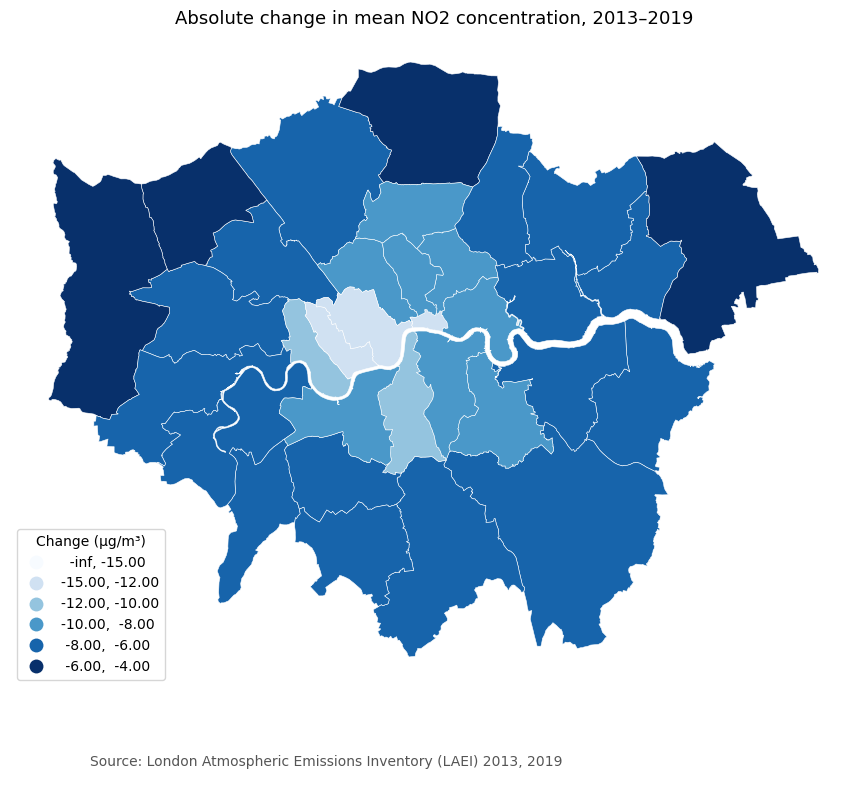

In [12]:
cbins_change = [-15, -12, -10, -8, -6, -4]

fig, ax1 = plt.subplots(1, figsize=(9, 9))

lad_gdf.plot(column='NO2_AbsD', ax=ax1,
             scheme='UserDefined',
             classification_kwds={'bins': cbins_change},
             cmap='Blues',
             edgecolor='white', linewidth=0.4,
             legend=True,
             legend_kwds={'title': 'Change (μg/m³)', 'loc': 'lower left'})

ax1.axis('off')
plt.title('Absolute change in mean NO2 concentration, 2013–2019', fontsize=13)

ax1.annotate('Source: London Atmospheric Emissions Inventory (LAEI) 2013, 2019',
             xy=(0.1, 0.06), xycoords='figure fraction',
             horizontalalignment='left', verticalalignment='top',
             fontsize=10, color='#555555')

fig.tight_layout()
plt.savefig('fig2_no2_change.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Descriptive Statistical Table

In [13]:
rows = []
for yr in ['2013', '2016', '2019']:
    col = f'NO2-{yr}-mean'
    rows.append({
        'Year': yr,
        'Mean (μg/m³)': round(lad_gdf[col].mean(), 2),
        'Std Dev':       round(lad_gdf[col].std(), 2),
        'Min':           round(lad_gdf[col].min(), 2),
        'Max':           round(lad_gdf[col].max(), 2)
    })

pd.DataFrame(rows)

,Year,Mean (μg/m³),Std Dev,Min,Max
0,2013,36.92,6.30,26.89,55.31
1,2016,36.92,5.48,27.81,52.49
2,2019,28.79,4.31,21.90,40.61


### Figure 3

In [14]:
w = weights.contiguity.Queen.from_dataframe(lad_gdf, ids=lad_gdf['LAD22NM'].tolist())
w.transform = 'R' 

print(f'Boroughs: {w.n}')
print(f'% non-zero weights: {round(w.pct_nonzero, 2)}')

Boroughs: 33
% non-zero weights: 12.49


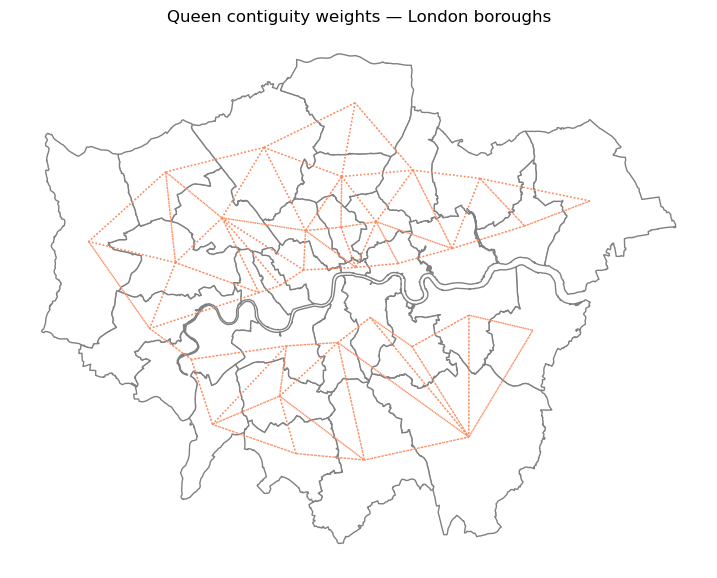

In [15]:
fig, axs = plt.subplots(1, figsize=(9, 9))

lad_gdf.plot(ax=axs, edgecolor='grey', facecolor='w')

w.plot(lad_gdf, ax=axs, indexed_on='LAD22NM',
       edge_kws=dict(color='#fc8d62', linestyle=':', linewidth=1),
       node_kws=dict(marker=''))

axs.set_title('Queen contiguity weights — London boroughs', fontsize=12)
axs.set_axis_off()
plt.show()

In [16]:
np.random.seed(10)
moran_no2 = esda.moran.Moran(lad_gdf['NO2-2019-mean'], w)

print(f"Moran's I  = {round(moran_no2.I, 4)}")
print(f"Expected I = {round(moran_no2.EI, 4)}")
print(f"p-value    = {round(moran_no2.p_sim, 4)}  (999 permutations)")

Moran's I  = 0.5735
Expected I = -0.0312
p-value    = 0.001  (999 permutations)


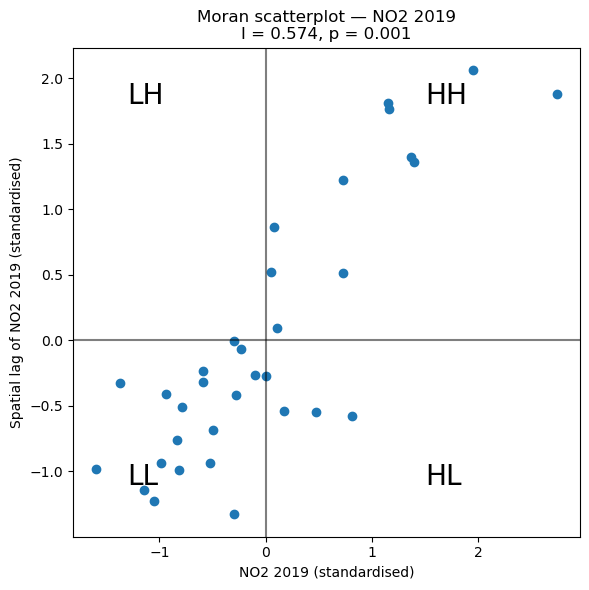

In [17]:
def standardize(df, var):
    newname = var + '_z'
    df[newname] = (df[var] - df[var].mean()) / df[var].std()

standardize(lad_gdf, 'NO2-2019-mean')
lad_gdf['NO2_lag_2019'] = weights.spatial_lag.lag_spatial(w, lad_gdf['NO2-2019-mean'])
standardize(lad_gdf, 'NO2_lag_2019')

fig, ax = plt.subplots(1, figsize=(6, 6))

plt.scatter(lad_gdf['NO2-2019-mean_z'], lad_gdf['NO2_lag_2019_z'])

ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)

plt.text(1.5,  1.8, "HH", fontsize=20)
plt.text(1.5, -1.1, "HL", fontsize=20)
plt.text(-1.3, 1.8, "LH", fontsize=20)
plt.text(-1.3,-1.1, "LL", fontsize=20)

ax.set_title(f"Moran scatterplot — NO2 2019\nI = {round(moran_no2.I, 3)}, p = {round(moran_no2.p_sim, 3)}")
ax.set_xlabel('NO2 2019 (standardised)')
ax.set_ylabel('Spatial lag of NO2 2019 (standardised)')

fig.tight_layout()
plt.savefig('fig3_moran_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 4

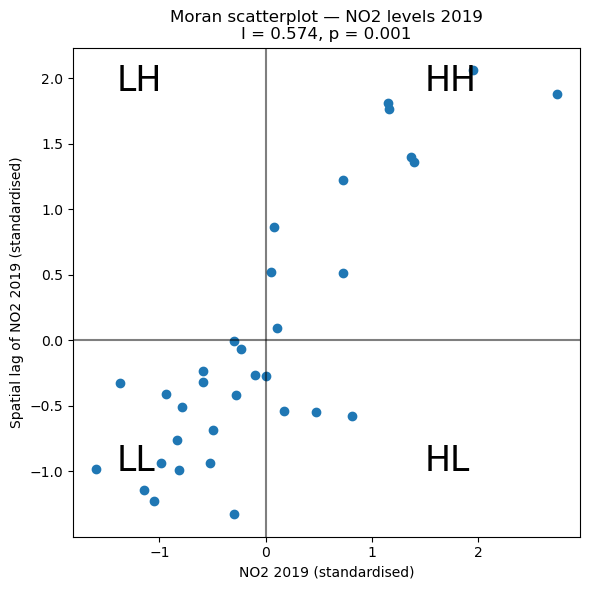

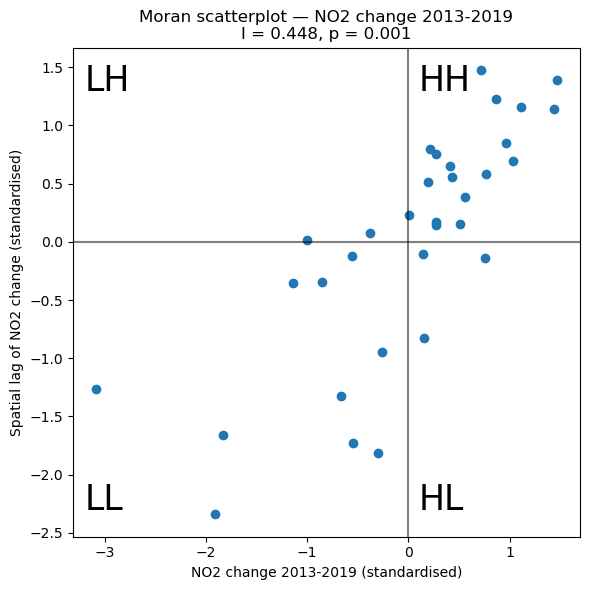

In [31]:
#Figure 4a
def standardize(df, var):
    newname = var + '_z'
    df[newname] = (df[var] - df[var].mean()) / df[var].std()

standardize(lad_gdf, 'NO2-2019-mean')
lad_gdf['NO2_lag_2019'] = weights.spatial_lag.lag_spatial(w, lad_gdf['NO2-2019-mean'])
standardize(lad_gdf, 'NO2_lag_2019')

fig, ax = plt.subplots(1, figsize=(6, 6))

plt.scatter(lad_gdf['NO2-2019-mean_z'], lad_gdf['NO2_lag_2019_z'])

ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)

ax.text(1.5,  1.9, "HH", fontsize=25)
ax.text(1.5, -1.0, "HL", fontsize=25)
ax.text(-1.4, 1.9, "LH", fontsize=25)
ax.text(-1.4,-1.0, "LL", fontsize=25)

ax.set_title(f"Moran scatterplot — NO2 levels 2019\nI = {round(moran_no2.I, 3)}, p = {round(moran_no2.p_sim, 3)}")
ax.set_xlabel('NO2 2019 (standardised)')
ax.set_ylabel('Spatial lag of NO2 2019 (standardised)')
fig.tight_layout()
plt.savefig('fig4a_moran_levels.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#Figure 4b
standardize(lad_gdf, 'NO2_AbsD')
lad_gdf['NO2_lag_change'] = weights.spatial_lag.lag_spatial(w, lad_gdf['NO2_AbsD'])
standardize(lad_gdf, 'NO2_lag_change')

fig, ax = plt.subplots(1, figsize=(6, 6))

plt.scatter(lad_gdf['NO2_AbsD_z'], lad_gdf['NO2_lag_change_z'])

ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)

ax.text(-3.2,  1.3, "LH", fontsize=25)
ax.text(0.1,   1.3, "HH", fontsize=25)
ax.text(-3.2, -2.3, "LL", fontsize=25)
ax.text(0.1,  -2.3, "HL", fontsize=25)

ax.set_title(f"Moran scatterplot — NO2 change 2013-2019\nI = {round(moran_change.I, 3)}, p = {round(moran_change.p_sim, 3)}")
ax.set_xlabel('NO2 change 2013-2019 (standardised)')
ax.set_ylabel('Spatial lag of NO2 change (standardised)')
fig.tight_layout()
plt.savefig('fig4b_moran_change.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 5

In [26]:
lisa_no2 = esda.moran.Moran_Local(lad_gdf['NO2-2019-mean'], w, seed=10)

fdr_no2 = esda.fdr(pvalues=lisa_no2.p_sim, alpha=0.05)
print(f'FDR-adjusted threshold (NO2 levels): {round(fdr_no2, 4)}')

lisa_change = esda.moran.Moran_Local(lad_gdf['NO2_AbsD'], w, seed=10)
fdr_change = esda.fdr(pvalues=lisa_change.p_sim, alpha=0.05)
print(f'FDR-adjusted threshold (NO2 change): {round(fdr_change, 4)}')

FDR-adjusted threshold (NO2 levels): 0.003
FDR-adjusted threshold (NO2 change): 0.0015


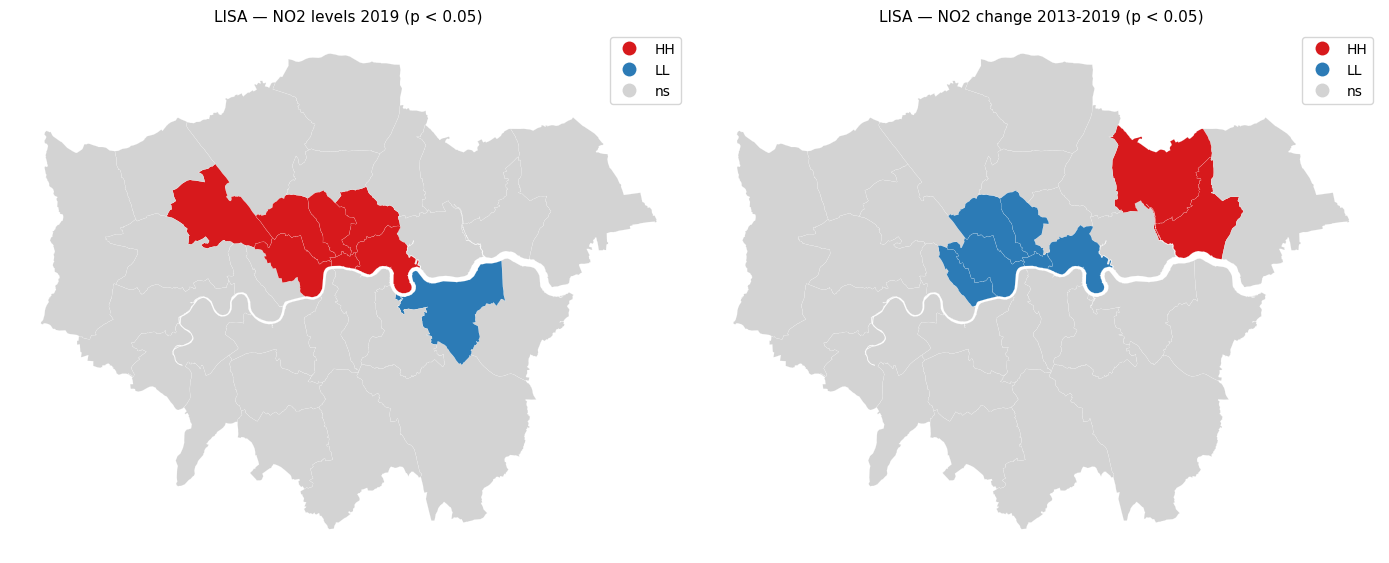

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

esdaplot.lisa_cluster(lisa_no2, lad_gdf, p=0.05, ax=axs[0])
axs[0].set_title('LISA — NO2 levels 2019 (p < 0.05)', fontsize=11)
axs[0].set_axis_off()

esdaplot.lisa_cluster(lisa_change, lad_gdf, p=0.05, ax=axs[1])
axs[1].set_title('LISA — NO2 change 2013-2019 (p < 0.05)', fontsize=11)
axs[1].set_axis_off()

fig.tight_layout()
plt.savefig('fig5_lisa_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 6

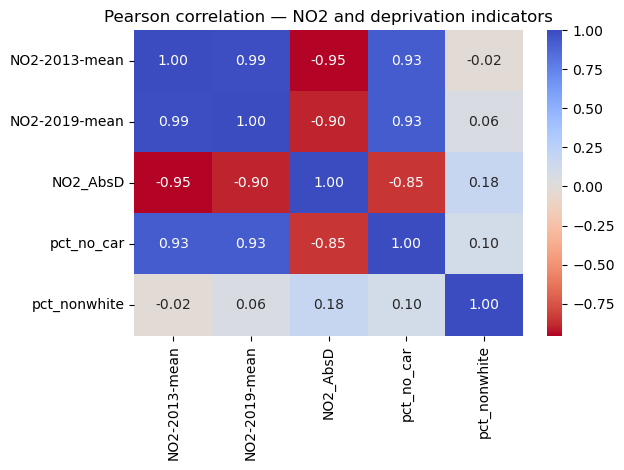

In [34]:
sub = lad_gdf[['NO2-2013-mean', 'NO2-2019-mean', 'NO2_AbsD', 'pct_no_car', 'pct_nonwhite']]
corrmat = sub.corr(numeric_only=True)

sb.heatmap(corrmat, cmap='coolwarm_r', annot=True, fmt='.2f')
plt.title('Pearson correlation — NO2 and deprivation indicators')
plt.tight_layout()
plt.savefig('fig6a_corrmat.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

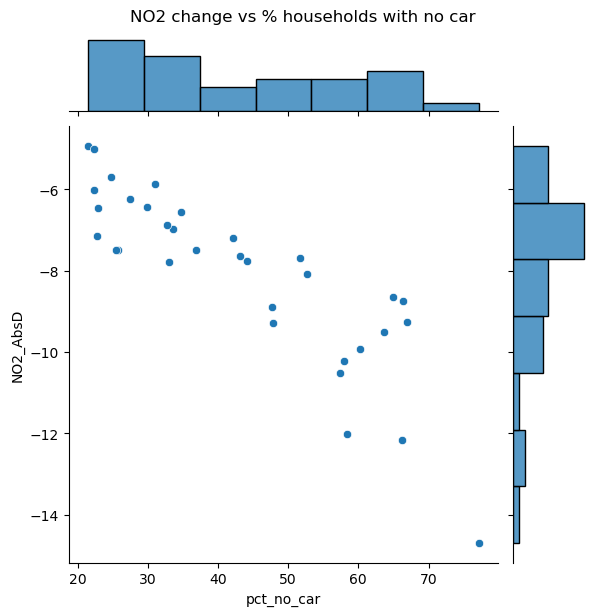

In [35]:
sb.jointplot(x='pct_no_car', y='NO2_AbsD', data=lad_gdf)
plt.suptitle('NO2 change vs % households with no car', y=1.02, fontsize=12)
plt.savefig('fig6b_joint_nocar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

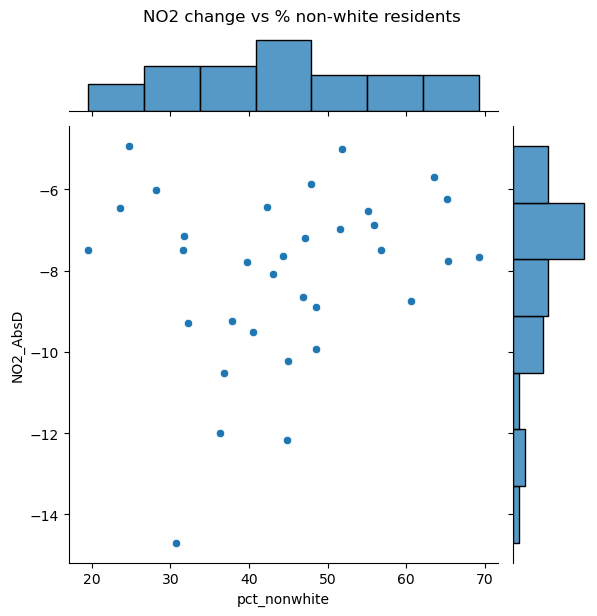

In [36]:
sb.jointplot(x='pct_nonwhite', y='NO2_AbsD', data=lad_gdf)
plt.suptitle('NO2 change vs % non-white residents', y=1.02, fontsize=12)
plt.savefig('fig6c_joint_nonwhite.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Gap Analysis

In [37]:
lad_gdf['dep_group'] = lad_gdf['pct_no_car'].apply(
    lambda x: 'High deprivation' if x > lad_gdf['pct_no_car'].median() else 'Low deprivation'
)

summary = lad_gdf.groupby('dep_group')[['NO2-2013-mean', 'NO2-2019-mean', 'NO2_AbsD']].mean(numeric_only=True)
summary.columns = ['Mean NO2 2013', 'Mean NO2 2019', 'Mean change']
summary = summary.round(2)

high = lad_gdf[lad_gdf['dep_group'] == 'High deprivation']
low  = lad_gdf[lad_gdf['dep_group'] == 'Low deprivation']

gap_2013 = high['NO2-2013-mean'].mean() - low['NO2-2013-mean'].mean()
gap_2019 = high['NO2-2019-mean'].mean() - low['NO2-2019-mean'].mean()

print(f'NO2 gap (high vs low deprivation) in 2013: {round(gap_2013, 2)} μg/m³')
print(f'NO2 gap (high vs low deprivation) in 2019: {round(gap_2019, 2)} μg/m³')
print(f'Change in gap: {round(gap_2019 - gap_2013, 2)} μg/m³  (negative = narrowed)')
print()
summary

NO2 gap (high vs low deprivation) in 2013: 9.56 μg/m³
NO2 gap (high vs low deprivation) in 2019: 6.46 μg/m³
Change in gap: -3.1 μg/m³  (negative = narrowed)



,Mean NO2 2013,Mean NO2 2019,Mean change
dep_group,,,
High deprivation,41.84,32.11,-9.69
Low deprivation,32.28,25.65,-6.57


### Figure 7

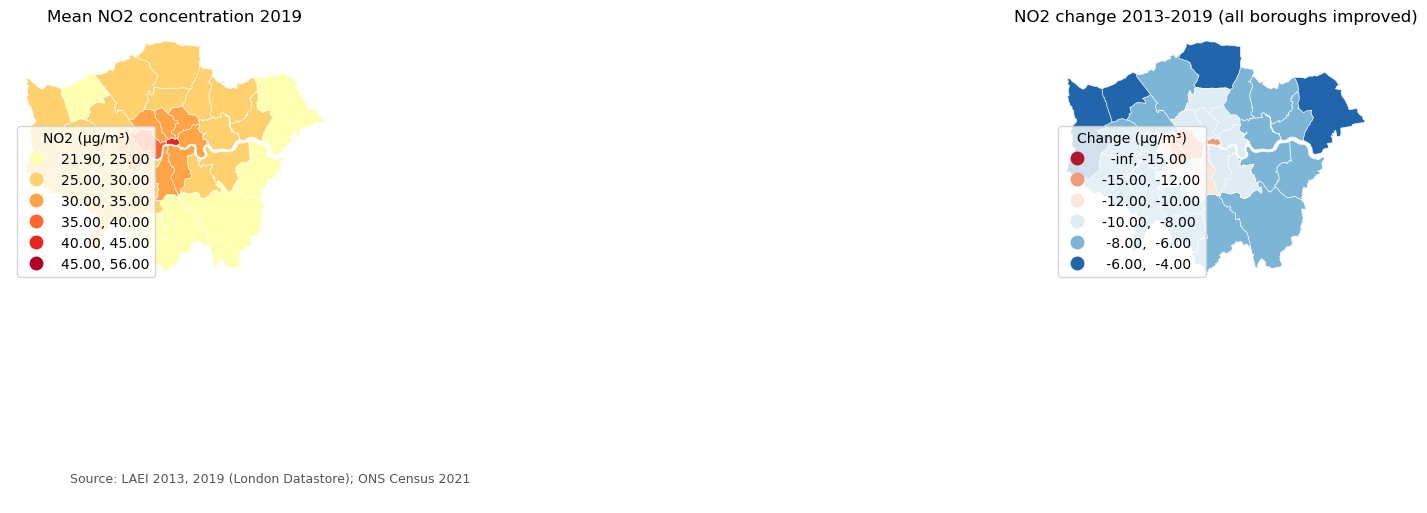

In [39]:
cbins_lev = [25, 30, 35, 40, 45, 56]
cbins_chg = [-15, -12, -10, -8, -6, -4]

fig, axs = plt.subplots(1, 2, figsize=(14, 7))

lad_gdf.plot(column='NO2-2019-mean', ax=axs[0],
             scheme='UserDefined',
             classification_kwds={'bins': cbins_lev},
             cmap=pcs.YlOrRd_7.mpl_colormap,
             edgecolor='white', linewidth=0.4,
             legend=True, legend_kwds={'title': 'NO2 (μg/m³)', 'loc': 'lower left'})
axs[0].axis('off')
axs[0].set_title('Mean NO2 concentration 2019', fontsize=12)

lad_gdf.plot(column='NO2_AbsD', ax=axs[1],
             scheme='UserDefined',
             classification_kwds={'bins': cbins_chg},
             cmap=pcd.RdBu_7.mpl_colormap,
             edgecolor='white', linewidth=0.4,
             legend=True, legend_kwds={'title': 'Change (μg/m³)', 'loc': 'lower left'})
axs[1].axis('off')
axs[1].set_title('NO2 change 2013-2019 (all boroughs improved)', fontsize=12)

axs[1].annotate('Source: LAEI 2013, 2019 (London Datastore); ONS Census 2021',
                xy=(0.05, 0.04), xycoords='figure fraction',
                horizontalalignment='left', verticalalignment='bottom',
                fontsize=9, color='#555555')

fig.tight_layout()
plt.savefig('fig7_summary_map.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()